In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/2026-1/학술제/텍스트분석/3000개 드가자.csv",encoding='cp949')

In [3]:
keyword_dict = {
    # -------------------------
    # Openness 관련
    # -------------------------
    "kw_art_expression": [
        "예술", "예술적", "감수성", "창작", "작가", "글쓰기", "사진", "스케치",
        "미술", "미술관", "갤러리", "수채화", "서예", "공예", "마크라메",
        "디자인", "인테리어", "큐레이터", "기획자", "콘텐츠", "영상", "편집",
        "음악", "재즈", "인디", "LP", "고미술", "건축", "현대미술"
    ],

    "kw_startup_project": [
        "창업", "공방", "가게", "카페", "소품샵", "편집숍", "책방", "반찬 가게",
        "밥집", "찻집", "게스트하우스", "온라인 판매", "쇼핑몰", "사업",
        "독립 프로젝트", "자신만의 공간", "살롱", "로컬 창업가", "작은 가게"
    ],

    "kw_learning_growth": [
        "배움", "학습", "공부", "자격증", "전문성", "성장", "도약", "연구",
        "석사", "전공", "지식", "지적", "탐구", "인문학", "철학", "법학",
        "공학", "ICT", "데이터", "분석", "디지털", "최신 기기"
    ],

    "kw_role_transition": [
        "이직", "전환", "재취업", "사회 진출", "새로운 역할", "제2의 인생",
        "제2막", "도약", "준비생", "구직", "취업 준비", "꿈꾸는", "희망하는",
        "지망생", "준비하는"
    ],

    "kw_routine_conservative": [
        "소박한 일상", "평범한 일상", "익숙한", "전통적", "보수적인",
        "현실적인", "실용적인", "정적인 휴식", "고요한 일상", "평온한 일상",
        "아날로그", "기존", "무던한"
    ],

    # -------------------------
    # Conscientiousness 관련
    # -------------------------
    "kw_diligence_basic": [
        "성실", "책임감", "묵묵히", "꾸준히", "헌신", "부양", "가족을 위해",
        "현실적인", "실속", "내실", "강인한", "단단한"
    ],

    "kw_precision_work": [
        "꼼꼼", "정밀", "정교", "치밀", "체계", "질서", "관리", "회계",
        "경리", "자재 관리", "품질 관리", "안전", "원칙", "정돈", "정갈",
        "계획", "실무 능력", "업무 처리", "전문 역량", "전문성"
    ],

    "kw_self_management": [
        "자기관리", "건강 관리", "혈당 관리", "체중 관리", "운동", "수영",
        "헬스", "필라테스", "걷기", "산책", "식단", "절제", "저축",
        "가계 관리", "정리정돈", "매일", "루틴"
    ],

    "kw_goal_action": [
        "자격증", "이직", "재취업", "취업 준비", "전문성 개발", "목표",
        "도약", "준비", "합격", "임용고시", "공무원", "주택관리사",
        "사회복지사", "전문가", "커리어", "성취", "야망"
    ],

    "kw_perfectionism": [
        "완벽주의", "강박", "높은 기준", "철저한", "한 치의 오차", "엄격",
        "매일의 계획", "정교하게 수행", "매우 강한", "집착", "통제"
    ],

    "kw_low_self_management": [
        "게으른", "나른함", "무직 상태", "구직 기간이 길어", "정체기",
        "미루", "서툰", "흐트러", "끊지 못", "관리에는 조금 서툰",
        "건강 관리가 시급", "건강 관리 필요성을 느끼면서도", "소홀함",
        "취약", "배달 음식", "게임으로 무료한 일상"
    ],

    # -------------------------
    # Stability preference 관련
    # -------------------------
    "kw_life_stability": [
        "안정", "평온", "평범한", "예측 가능한", "정서적 평온", "일상의 안정",
        "소박한 행복", "생활 기반", "기반", "유지", "균형", "안식",
        "휴식", "가족의 안녕", "가족의 안정", "평온한 노후"
    ],

    "kw_family_housing": [
        "가족", "자녀", "부모님", "어머니", "아내", "남편", "손주",
        "부양", "한부모", "대가족", "내 집 마련", "자가", "주거 안정",
        "보금자리", "단독주택", "아파트", "집", "주택"
    ],

    "kw_health_risk": [
        "건강", "당뇨", "고혈압", "혈당", "비만", "고도비만", "복부비만",
        "체중", "통증", "건강 악화", "건강 고민", "건강 문제", "건강 회복",
        "건강 관리가 시급", "질환", "몸", "체형"
    ],

    "kw_economic_job_insecurity": [
        "불안정", "고용", "소득", "경제적 불안", "빠듯한", "넉넉지 않은",
        "무직", "구직", "취업난", "재취업", "취업 준비", "현실의 무게",
        "경제적 결핍", "낮은 소득", "내 집 마련", "저축", "노후 준비",
        "미래 불안", "주거 불안"
    ],

    "kw_emotional_anxiety": [
        "불안", "두려움", "걱정", "예민", "위축", "갈등", "외로움",
        "고독", "쓸쓸함", "정서적 소모", "심리적 불안", "내면의 불안",
        "망설", "문단속", "집착", "강박"
    ],

    "kw_change_flexibility": [
        "자유로운", "유연한", "독립적인", "새로운 환경", "도전", "변화",
        "즉흥", "여행", "홀로", "독립", "실험적", "자유", "탐색",
        "크리에이터", "사업적 확장"
    ]
}

In [4]:
import re

def count_keywords(text, keywords):
    text = str(text)
    count = 0
    for kw in keywords:
        count += len(re.findall(re.escape(kw), text))
    return count

def add_keyword_features(df, text_col, keyword_dict):
    df = df.copy()

    for group_name, keywords in keyword_dict.items():
        count_col = f"{group_name}_count"
        has_col = f"{group_name}_has"

        df[count_col] = df[text_col].apply(lambda x: count_keywords(x, keywords))
        df[has_col] = (df[count_col] > 0).astype(int)

    return df

df = add_keyword_features(df, "persona", keyword_dict)

keyword_feature_cols = []
for group_name in keyword_dict.keys():
    keyword_feature_cols.append(f"{group_name}_count")
    keyword_feature_cols.append(f"{group_name}_has")

df[keyword_feature_cols].head()

,kw_art_expression_count,kw_art_expression_has,kw_startup_project_count,kw_startup_project_has,kw_learning_growth_count,kw_learning_growth_has,kw_role_transition_count,kw_role_transition_has,kw_routine_conservative_count,kw_routine_conservative_has,...,kw_family_housing_count,kw_family_housing_has,kw_health_risk_count,kw_health_risk_has,kw_economic_job_insecurity_count,kw_economic_job_insecurity_has,kw_emotional_anxiety_count,kw_emotional_anxiety_has,kw_change_flexibility_count,kw_change_flexibility_has
0,0,0,1,1,3,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,1,1,0,0,2,1,...,1,1,0,0,0,0,0,0,0,0
4,2,1,0,0,1,1,1,1,0,0,...,1,1,1,1,0,0,0,0,3,1


In [5]:
keyword_summary = pd.DataFrame({
    "feature": keyword_feature_cols,
    "sum": [df[col].sum() for col in keyword_feature_cols],
    "mean": [df[col].mean() for col in keyword_feature_cols]
}).sort_values("sum", ascending=False)

keyword_summary

,feature,sum,mean
24,kw_family_housing_count,2192,0.730667
12,kw_precision_work_count,1960,0.653333
25,kw_family_housing_has,1570,0.523333
0,kw_art_expression_count,1475,0.491667
10,kw_diligence_basic_count,1430,0.476667
13,kw_precision_work_has,1403,0.467667
22,kw_life_stability_count,1354,0.451333
4,kw_learning_growth_count,1107,0.369000
11,kw_diligence_basic_has,1087,0.362333
23,kw_life_stability_has,1053,0.351000


In [6]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("jhgan/ko-sroberta-multitask")

X_embedding = embed_model.encode(
    df["persona"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

X_embedding.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

(3000, 768)

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_keyword_raw = df[keyword_feature_cols].values

keyword_scaler = StandardScaler()
X_keyword = keyword_scaler.fit_transform(X_keyword_raw)

X = np.hstack([X_embedding, X_keyword])

target_cols = ["openness", "conscientiousness", "stability_preference"]
y = df[target_cols].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 802)
y shape: (3000, 3)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X,
    y,
    df.index,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(2400, 802) (600, 802)


In [11]:
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

ridge_model = MultiOutputRegressor(
    Ridge(alpha=10.0, random_state=42)
)

ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)
y_pred = np.clip(y_pred, 1, 5)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_multioutput(y_true, y_pred, target_cols):
    rows = []

    for i, col in enumerate(target_cols):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        rows.append({
            "target": col,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(rows)

eval_df = evaluate_multioutput(y_test, y_pred, target_cols)
eval_df

,target,MAE,RMSE,R2
0,openness,0.319179,0.431528,0.657859
1,conscientiousness,0.366271,0.465145,0.440626
2,stability_preference,0.367796,0.463317,0.573367


In [13]:
X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_embedding,
    y,
    test_size=0.2,
    random_state=42
)

ridge_emb_only = MultiOutputRegressor(
    Ridge(alpha=10.0, random_state=42)
)

ridge_emb_only.fit(X_emb_train, y_emb_train)

y_emb_pred = ridge_emb_only.predict(X_emb_test)
y_emb_pred = np.clip(y_emb_pred, 1, 5)

eval_emb_only = evaluate_multioutput(y_emb_test, y_emb_pred, target_cols)
eval_emb_only["model"] = "embedding_only"

eval_hybrid = eval_df.copy()
eval_hybrid["model"] = "embedding_plus_keywords"

compare_eval = pd.concat([eval_emb_only, eval_hybrid], ignore_index=True)
compare_eval[["model", "target", "MAE", "RMSE", "R2"]]

,model,target,MAE,RMSE,R2
0,embedding_only,openness,0.380010,0.494003,0.551619
1,embedding_only,conscientiousness,0.395592,0.490513,0.377947
2,embedding_only,stability_preference,0.413279,0.518129,0.466451
3,embedding_plus_keywords,openness,0.319179,0.431528,0.657859
4,embedding_plus_keywords,conscientiousness,0.366271,0.465145,0.440626
5,embedding_plus_keywords,stability_preference,0.367796,0.463317,0.573367


In [14]:
test_result = df.loc[test_idx, ["name", "persona"]].copy()

for i, col in enumerate(target_cols):
    test_result[f"{col}_true"] = y_test[:, i]
    test_result[f"{col}_pred"] = y_pred[:, i].round(2)
    test_result[f"{col}_error"] = (test_result[f"{col}_pred"] - test_result[f"{col}_true"]).round(2)

test_result.head(20)

,name,persona,openness_true,openness_pred,openness_error,conscientiousness_true,conscientiousness_pred,conscientiousness_error,stability_preference_true,stability_preference_pred,stability_preference_error
1801,노제혁,"노제혁 씨는 문경에서 성실하게 근무하는 경비원이자, 가족의 안녕과 자녀의 성공을 위...",3,2.94,-0.06,3,3.39,0.39,4,3.82,-0.18
1190,구수연,"구수연 씨는 영덕 강구항의 넉살 좋은 아주머니로, 텃밭 가꾸기와 트로트 감상을 즐기...",3,2.86,-0.14,3,2.54,-0.46,3,2.76,-0.24
1817,신미정,신미정 씨는 해운대에서 병원 청소원으로 일하며 성실하게 삶을 일궈온 57세 여성으로...,2,2.43,0.43,3,3.25,0.25,3,3.18,0.18
251,김상무,"김상무 씨는 동작구 상도동에서 성실하게 살아온 60대 가장으로, 콜센터 상담원의 인...",2,2.91,0.91,4,3.43,-0.57,3,3.59,0.59
2505,허승희,"허승희 씨는 대전 유성구에서 금융 영업원으로 일하며, 다정한 소통 능력과 세심한 관...",3,3.21,0.21,3,3.17,0.17,3,3.29,0.29
1117,유용수,"유용수 씨는 강원도 인제에서 성실하게 일하며 가족과 자연을 사랑하는, 투박하지만 따...",3,2.90,-0.10,3,2.84,-0.16,3,3.23,0.23
1411,김종문,"김종문 씨는 경기 군포에서 성실하게 기계를 조작하며 가족의 안정을 일궈낸, 묵묵하고...",3,3.09,0.09,4,3.10,-0.90,4,3.78,-0.22
2113,홍희란,"홍희란 씨는 대전 유성구에서 성실하게 주방 보조로 일하며, 철저한 자기관리와 소박한...",3,3.02,0.02,5,4.50,-0.50,4,3.34,-0.66
408,장동화,"장동화 씨는 공학적 정밀함으로 공장 장부를 관리하는 꼼꼼한 경리 사무원이자, 태안 ...",3,3.29,0.29,4,4.07,0.07,3,3.10,0.10
2579,서영주,"서영주 씨는 의왕시에 거주하며 법무 전문성을 바탕으로 사회 봉사를 꿈꾸는, 지적 탐...",3,3.28,0.28,4,4.10,0.10,4,3.54,-0.46


In [15]:
test_result["total_abs_error"] = (
    test_result["openness_error"].abs()
    + test_result["conscientiousness_error"].abs()
    + test_result["stability_preference_error"].abs()
)

test_result.sort_values("total_abs_error", ascending=False).head(20)

,name,persona,openness_true,openness_pred,openness_error,conscientiousness_true,conscientiousness_pred,conscientiousness_error,stability_preference_true,stability_preference_pred,stability_preference_error,total_abs_error
96,범진호,범진호 씨는 정밀한 설계 역량을 갖췄으나 취업의 압박 속에 동작구 자가 아파트에서 ...,3,2.49,-0.51,2,4.14,2.14,5,3.81,-1.19,3.84
2001,임준교,"임준교 씨는 인천 남동공단의 지리를 꿰뚫고 있는 성실한 화물차 운전원으로, 테니스와...",4,2.48,-1.52,5,3.61,-1.39,3,3.25,0.25,3.16
1036,박승화,박승화 씨는 천안에서 자동차 부품사 비서로 일하며 업무 효율을 극대화하는 유능한 직...,2,2.61,0.61,5,3.69,-1.31,5,3.96,-1.04,2.96
543,김다희,"김다희 씨는 김포의 내 집에서 누리는 정적과 안락함을 삶의 최우선 가치로 삼으며, ...",4,2.76,-1.24,5,3.49,-1.51,3,3.17,0.17,2.92
407,강진한,"강진한 씨는 이른 사회생활로 삶의 무게를 일찍 깨달았지만, 성실한 태도로 전문성을 ...",4,2.81,-1.19,4,3.15,-0.85,4,3.38,-0.62,2.66
210,한갑숙,한갑숙 씨는 의정부에서 금융 사무원으로 근무하며 성실함과 유연함을 겸비한 40대 여...,2,2.99,0.99,3,3.84,0.84,4,3.20,-0.80,2.63
1830,윤장열,"윤장열 씨는 완벽주의적 성향의 공직자로서 내면의 불안을 예술과 자연, 그리고 체계적...",3,3.87,0.87,5,4.52,-0.48,5,3.74,-1.26,2.61
368,김윤기,김윤기 씨는 양산에서 소규모 상점을 운영하며 안정적인 삶과 동네 사람들과의 정을 소...,2,2.95,0.95,4,3.00,-1.00,4,3.36,-0.64,2.59
605,양명희,양명희 씨는 양천구의 전세 집에서 자녀를 홀로 키우며 낡은 소프트웨어 코드를 고치는...,3,3.55,0.55,3,3.26,0.26,5,3.33,-1.67,2.48
233,이승렬,이승렬 씨는 보수적인 대구의 환경에서 공무원 시험을 준비하는 고도비만의 29세 청년...,5,3.52,-1.48,4,3.60,-0.40,4,3.43,-0.57,2.45


In [16]:
df_pred = df.copy()

all_pred = ridge_model.predict(X)
all_pred = np.clip(all_pred, 1, 5)

for i, col in enumerate(target_cols):
    df_pred[f"{col}_pred"] = all_pred[:, i].round(3)

df_pred[["name", "openness", "openness_pred",
         "conscientiousness", "conscientiousness_pred",
         "stability_preference", "stability_preference_pred"]].head()

,name,openness,openness_pred,conscientiousness,conscientiousness_pred,stability_preference,stability_preference_pred
0,최진혁,5,3.863,3,3.513,3,2.918
1,이정섭,3,2.995,4,3.960,3,2.738
2,최일배,3,2.785,4,3.361,4,3.849
3,방선미,4,2.712,3,2.800,3,3.450
4,이진원,5,4.552,3,3.150,2,2.487


In [17]:
score_cols = [
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred"
]

score_scaler = StandardScaler()
score_z = score_scaler.fit_transform(df_pred[score_cols])

df_pred["openness_z"] = score_z[:, 0]
df_pred["conscientiousness_z"] = score_z[:, 1]
df_pred["stability_preference_z"] = score_z[:, 2]

In [18]:
from sklearn.decomposition import PCA
import numpy as np

# PCA에 사용할 Z-score 표준화된 예측 점수 컬럼
pca_features = ['openness_z', 'conscientiousness_z', 'stability_preference_z']

# PCA 모델 생성 및 학습
pca = PCA(n_components=1) # 첫 번째 주성분만 사용
principal_components = pca.fit_transform(df_pred[pca_features])

# 첫 번째 주성분(PC1)의 가중치 (고유벡터)
# 이 가중치들이 각 특성이 PC1에 기여하는 정도를 나타냅니다.
# 이 가중치를 risk_tendency_score 계산에 사용할 수 있습니다.

pca_weights = pca.components_[0]

print("PCA Component Loadings (Weights):")
for i, feature in enumerate(pca_features):
    print(f"{feature}: {pca_weights[i]:.4f}")

# PCA 가중치를 사용하여 새로운 risk_tendency_score 계산
df_pred['risk_tendency_score_pca'] = np.dot(df_pred[pca_features], pca_weights)

print("\n새로운 'risk_tendency_score_pca'의 기술 통계량:")
display(df_pred['risk_tendency_score_pca'].describe())

PCA Component Loadings (Weights):
openness_z: 0.7072
conscientiousness_z: 0.0060
stability_preference_z: -0.7070

새로운 'risk_tendency_score_pca'의 기술 통계량:


,risk_tendency_score_pca
count,3.000000e+03
mean,-6.205407e-16
std,1.144870e+00
min,-3.396115e+00
25%,-7.904503e-01
50%,-1.566035e-03
75%,7.493254e-01
max,3.627216e+00


In [19]:
df_pred["risk_tendency_score_pca"].describe()

,risk_tendency_score_pca
count,3.000000e+03
mean,-6.205407e-16
std,1.144870e+00
min,-3.396115e+00
25%,-7.904503e-01
50%,-1.566035e-03
75%,7.493254e-01
max,3.627216e+00


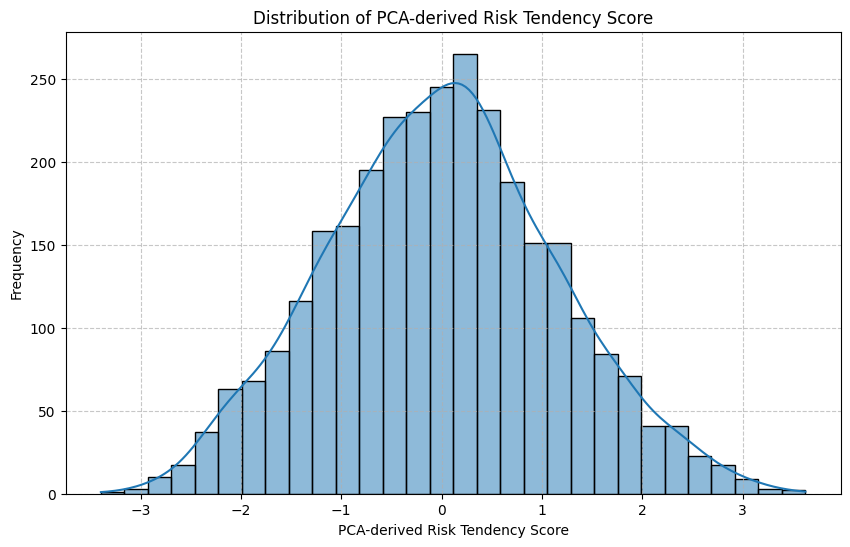

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_pred['risk_tendency_score_pca'], bins=30, kde=True)
plt.title('Distribution of PCA-derived Risk Tendency Score')
plt.xlabel('PCA-derived Risk Tendency Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [21]:
df_pred["risk_profile_5"] = pd.qcut(
    df_pred["risk_tendency_score_pca"],
    q=5,
    labels=[
        "매우 보수형",
        "보수형",
        "중립형",
        "적극형",
        "공격형"
    ]
)

In [22]:
df_pred["risk_profile_3"] = pd.qcut(
    df_pred["risk_tendency_score_pca"],
    q=3,
    labels=[
        "안정형",
        "균형형",
        "성장형"
    ]
)

In [23]:
df_pred[[
    "name",
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred",
    "risk_tendency_score_pca",
    "risk_profile_3",
    "risk_profile_5"
]].head(20)

,name,openness_pred,conscientiousness_pred,stability_preference_pred,risk_tendency_score_pca,risk_profile_3,risk_profile_5
0,최진혁,3.863,3.513,2.918,1.508434,성장형,공격형
1,이정섭,2.995,3.960,2.738,0.749893,성장형,적극형
2,최일배,2.785,3.361,3.849,-0.894126,안정형,보수형
3,방선미,2.712,2.800,3.450,-0.483116,균형형,보수형
4,이진원,4.552,3.150,2.487,2.831854,성장형,공격형
5,김유정,2.786,3.088,3.576,-0.553332,안정형,보수형
6,김민규,2.905,2.861,3.595,-0.444344,균형형,보수형
7,윤현정,3.425,3.194,3.043,0.847312,성장형,적극형
8,박조아,4.428,3.146,3.134,1.876959,성장형,공격형
9,안형전,3.001,3.749,3.204,0.168213,균형형,중립형


In [24]:
print(df_pred["risk_profile_3"].value_counts())
print()
print(df_pred["risk_profile_5"].value_counts())

risk_profile_3
안정형    1000
균형형    1000
성장형    1000
Name: count, dtype: int64

risk_profile_5
매우 보수형    600
보수형       600
중립형       600
적극형       600
공격형       600
Name: count, dtype: int64


In [25]:
output_cols = [
    "name",
    "persona",
    "openness",
    "conscientiousness",
    "stability_preference",
    "openness_pred",
    "conscientiousness_pred",
    "stability_preference_pred",
    "risk_tendency_score_pca",
    "risk_profile_3",
    "risk_profile_5"
]

df_pred[output_cols].to_csv(
    "persona_modeling_scoring_result.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: persona_modeling_scoring_result.csv")

저장 완료: persona_modeling_scoring_result.csv


In [26]:
def make_keyword_features_for_text(text, keyword_dict):
    row = {}

    for group_name, keywords in keyword_dict.items():
        count = count_keywords(text, keywords)
        row[f"{group_name}_count"] = count
        row[f"{group_name}_has"] = int(count > 0)

    return pd.DataFrame([row])


def predict_persona_scores(persona_text):
    # 1. 임베딩
    emb = embed_model.encode(
        [persona_text],
        convert_to_numpy=True
    )

    # 2. 키워드 변수
    kw_df = make_keyword_features_for_text(persona_text, keyword_dict)
    kw_raw = kw_df[keyword_feature_cols].values
    kw_scaled = keyword_scaler.transform(kw_raw)

    # 3. 결합
    X_new = np.hstack([emb, kw_scaled])

    # 4. 심리 점수 예측
    pred = ridge_model.predict(X_new)
    pred = np.clip(pred, 1, 5)[0]

    result = {
        "openness_pred": float(pred[0]),
        "conscientiousness_pred": float(pred[1]),
        "stability_preference_pred": float(pred[2])
    }

    return result

In [27]:
def predict_persona_scores(persona_text):
    # 1. 임베딩
    emb = embed_model.encode(
        [persona_text],
        convert_to_numpy=True
    )

    # 2. 키워드 변수
    kw_df = make_keyword_features_for_text(persona_text, keyword_dict)
    kw_raw = kw_df[keyword_feature_cols].values
    kw_scaled = keyword_scaler.transform(kw_raw)

    # 3. 결합
    X_new = np.hstack([emb, kw_scaled])

    # 4. 심리 점수 예측
    pred = ridge_model.predict(X_new)
    pred = np.clip(pred, 1, 5)[0]

    openness = float(pred[0])
    conscientiousness = float(pred[1])
    stability_preference = float(pred[2])

    # 5. z-score 변환
    openness_z = (openness - score_stats["openness"]["mean"]) / score_stats["openness"]["std"]
    conscientiousness_z = (conscientiousness - score_stats["conscientiousness"]["mean"]) / score_stats["conscientiousness"]["std"]
    stability_preference_z = (stability_preference - score_stats["stability_preference"]["mean"]) / score_stats["stability_preference"]["std"]

    # 6. PCA 기반 risk score
    risk_score = (
        0.7072 * openness_z
        + 0.0060 * conscientiousness_z
        - 0.7070 * stability_preference_z
    )

    result = {
        "openness_pred": openness,
        "conscientiousness_pred": conscientiousness,
        "stability_preference_pred": stability_preference,
        "openness_z": float(openness_z),
        "conscientiousness_z": float(conscientiousness_z),
        "stability_preference_z": float(stability_preference_z),
        "risk_score": float(risk_score)
    }

    return result

In [35]:
def analyze_persona_prediction(persona_text, true_openness=None, true_conscientiousness=None, true_stability_preference=None):
    predictions = predict_persona_scores(persona_text)

    print(f"### Persona Analysis: {persona_text.strip()[:50]}... ###")
    print(f"예측된 Openness: {predictions['openness_pred']:.2f}")
    print(f"예측된 Conscientiousness: {predictions['conscientiousness_pred']:.2f}")
    print(f"예측된 Stability Preference: {predictions['stability_preference_pred']:.2f}")

    if true_openness is not None and true_conscientiousness is not None and true_stability_preference is not None:
        openness_error = predictions['openness_pred'] - true_openness
        conscientiousness_error = predictions['conscientiousness_pred'] - true_conscientiousness
        stability_preference_error = predictions['stability_preference_pred'] - true_stability_preference

        print(f"\n실제 Openness: {true_openness}, 오차: {openness_error:.2f}")
        print(f"실제 Conscientiousness: {true_conscientiousness}, 오차: {conscientiousness_error:.2f}")
        print(f"실제 Stability Preference: {true_stability_preference}, 오차: {stability_preference_error:.2f}")
    else:
        print("\n실제 점수가 제공되지 않아 오차는 계산되지 않습니다.")

    return predictions

이제 이 함수를 사용하여 특정 페르소나의 예측 점수와 실제 점수(알고 있는 경우)를 비교해 볼 수 있습니다.

In [36]:
# 예시 1: 실제 점수를 아는 페르소나 (예: df에서 가져와서 비교)
# `df` 데이터프레임에서 첫 번째 행의 'persona'와 실제 점수를 사용하여 테스트합니다.
first_persona_text = df.loc[0, 'persona']
first_openness = df.loc[0, 'openness']
first_conscientiousness = df.loc[0, 'conscientiousness']
first_stability_preference = df.loc[0, 'stability_preference']

analyze_persona_prediction(
    first_persona_text,
    true_openness=first_openness,
    true_conscientiousness=first_conscientiousness,
    true_stability_preference=first_stability_preference
)

### Persona Analysis: 최진혁 씨는 법학 전공자의 논리적인 분석력과 광주 광산구의 여유로운 삶을 동시에 가진, 창... ###
예측된 Openness: 3.86
예측된 Conscientiousness: 3.51
예측된 Stability Preference: 2.92

실제 Openness: 5, 오차: -1.14
실제 Conscientiousness: 3, 오차: 0.51
실제 Stability Preference: 3, 오차: -0.08


{'openness_pred': 3.862728811822593,
 'conscientiousness_pred': 3.5134908924102053,
 'stability_preference_pred': 2.9175630965811825,
 'openness_z': 0.9106700074239894,
 'conscientiousness_z': 0.11263613136135738,
 'stability_preference_z': -0.820460146247789,
 'risk_score': 1.2247669694356003}

In [37]:
# 예시 2: 새로운 페르소나에 대한 예측 (실제 점수 없음)
new_persona_example = """
김영희 씨는 평범한 직장인이지만 퇴근 후에는 인문학 강의를 듣고 글쓰기 모임에 참여하는 것을 즐깁니다. 새로운 지식 습득에 대한 열정이 높고, 주말에는 가까운 미술관이나 도서관을 찾아 시간을 보냅니다.
"""

analyze_persona_prediction(new_persona_example)

### Persona Analysis: 김영희 씨는 평범한 직장인이지만 퇴근 후에는 인문학 강의를 듣고 글쓰기 모임에 참여하는 것... ###
예측된 Openness: 4.55
예측된 Conscientiousness: 3.44
예측된 Stability Preference: 2.93

실제 점수가 제공되지 않아 오차는 계산되지 않습니다.


{'openness_pred': 4.546042105720266,
 'conscientiousness_pred': 3.4400392580734263,
 'stability_preference_pred': 2.932696497064824,
 'openness_z': 1.8265915025308221,
 'conscientiousness_z': -0.005851511656000725,
 'stability_preference_z': -0.7992030394435664,
 'risk_score': 1.856766950406463}

In [29]:
score_stats = {
    "openness": {
        "mean": df["openness"].mean(),
        "std": df["openness"].std()
    },
    "conscientiousness": {
        "mean": df["conscientiousness"].mean(),
        "std": df["conscientiousness"].std()
    },
    "stability_preference": {
        "mean": df["stability_preference"].mean(),
        "std": df["stability_preference"].std()
    }
}

In [30]:
new_persona = """
김민수 씨는 안정적인 직장을 다니면서도 주말마다 사진 촬영과 작은 공방 창업을 꿈꾸는 30대 직장인입니다.
가족의 생활 기반을 중요하게 여기지만 새로운 시도에도 관심이 많고, 자격증 공부를 통해 미래를 준비하고 있습니다.
"""

predict_persona_scores(new_persona)

{'openness_pred': 5.0,
 'conscientiousness_pred': 3.6494929760252868,
 'stability_preference_pred': 3.3353176679175895,
 'openness_z': 2.4350822152938436,
 'conscientiousness_z': 0.33202629848976534,
 'stability_preference_z': -0.23366185524575134,
 'risk_score': 1.889281232105491}

In [32]:
new_persona = """
동규서씨는 안정적인 직장을 얻기 위해 열심히 취업준비를 하고있는 20대 중반의 사회 초년생입니다. 안정적인 수입원은 없으며 부모님의 용돈으로 생계유지를 하고있습니다. 주말마다 축구를 하며 가끔씩 산책을 즐기기도 합니다
"""

predict_persona_scores(new_persona)

{'openness_pred': 2.6064931512751572,
 'conscientiousness_pred': 3.094976577935591,
 'stability_preference_pred': 3.951769703843209,
 'openness_z': -0.7732036339798497,
 'conscientiousness_z': -0.5624853297045149,
 'stability_preference_z': 0.6322365118473665,
 'risk_score': -0.9971757358048648}

In [33]:
raw_preds = ridge_model.predict(X)

clip_low = (raw_preds < 1).mean(axis=0)
clip_high = (raw_preds > 5).mean(axis=0)

print("1보다 작게 예측된 비율:", clip_low)
print("5보다 크게 예측된 비율:", clip_high)

1보다 작게 예측된 비율: [0. 0. 0.]
5보다 크게 예측된 비율: [0.01233333 0.008      0.01633333]


In [34]:
raw_preds = ridge_model.predict(X)

pred_df = pd.DataFrame(
    raw_preds,
    columns=["openness_raw", "conscientiousness_raw", "stability_preference_raw"]
)

pred_df.describe()

,openness_raw,conscientiousness_raw,stability_preference_raw
count,3000.000000,3000.000000,3000.000000
mean,3.181942,3.443611,3.499123
std,0.631538,0.474852,0.572924
min,1.631939,2.186898,1.744321
25%,2.804425,3.110589,3.079085
50%,3.059935,3.362132,3.383949
75%,3.526293,3.689711,3.832731
max,5.879971,5.919269,6.008483
